# Benchmark Clustering — Shared-Model Distance
Distance between two benchmarks = mean absolute z-score difference across models tested on both.
This avoids filling missing data and only compares benchmarks on their shared models.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import os

In [10]:
# Load all 50 benchmarks
BENCHMARKS = {
    'adversarial_nli_external.csv': 'Score',
    'aider_polyglot_external.csv': 'Percent correct',
    'apex_agents_external.csv': 'Pass@1 score',
    'arc_agi_2_external.csv': 'Score',
    'arc_agi_external.csv': 'Score',
    'arc_ai2_external.csv': 'Challenge score',
    'balrog_external.csv': 'Average progress',
    'bbh_external.csv': 'Average',
    'bool_q_external.csv': 'Score',
    'cad_eval_external.csv': 'Overall pass (%)',
    'chess_puzzles.csv': 'mean_score',
    'common_sense_qa_2_external.csv': 'Score',
    'cybench_external.csv': 'Unguided % Solved',
    'deepresearchbench_external.csv': 'Average score',
    'epoch_capabilities_index.csv': 'ECI Score',
    'fictionlivebench_external.csv': '120k token score',
    'frontiermath.csv': 'mean_score',
    'frontiermath_tier_4.csv': 'mean_score',
    'gdpval_external.csv': 'Win Rate (%)',
    'geobench_external.csv': 'ACW Avg Score',
    'gpqa_diamond.csv': 'mean_score',
    'gsm8k_external.csv': 'EM',
    'gso_external.csv': 'Score OPT@1',
    'hella_swag_external.csv': 'Overall accuracy',
    'hle_external.csv': 'Accuracy',
    'lambada_external.csv': 'Score',
    'lech_mazur_writing_external.csv': 'Mean score',
    'live_bench_external.csv': 'Global average',
    'math_level_5.csv': 'mean_score',
    'metr_time_horizons_external.csv': 'Time horizon',
    'mmlu_external.csv': 'EM',
    'open_book_qa_external.csv': 'Accuracy',
    'os_world_external.csv': 'Score',
    'otis_mock_aime_2024_2025.csv': 'mean_score',
    'piqa_external.csv': 'Score',
    'posttrainbench_external.csv': 'Average (%)',
    'science_qa_external.csv': 'Score',
    'simplebench_external.csv': 'Score (AVG@5)',
    'simpleqa_verified.csv': 'mean_score',
    'superglue_external.csv': 'Score',
    'swe_bench_bash.csv': '% Resolved',
    'swe_bench_verified.csv': 'mean_score',
    'terminalbench_external.csv': 'Accuracy mean',
    'the_agent_company_external.csv': '% Score',
    'trivia_qa_external.csv': 'EM',
    'video_mme_external.csv': 'Overall (no subtitles)',
    'vpct_external.csv': 'Correct',
    'webdev_arena_external.csv': 'Arena Score',
    'weirdml_external.csv': 'Accuracy',
    'wino_grande_external.csv': 'Accuracy',
}

MIN_MODELS = 10  # drop benchmarks with fewer than this many models

DATA_DIR = os.path.join('..', 'benchmark_data')
frames = {}
for csv_file, score_col in BENCHMARKS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, csv_file))
    df = df[['Model version', score_col]].dropna()
    bm_name = csv_file.replace('.csv', '')
    df = df.rename(columns={score_col: bm_name})
    df = df.groupby('Model version').mean(numeric_only=True)
    frames[csv_file] = df

merged = pd.concat(frames.values(), axis=1, join='outer')

# Filter 1: drop benchmarks with too few models
model_counts = merged.notna().sum()
dropped_small = model_counts[model_counts < MIN_MODELS].index.tolist()
merged = merged.drop(columns=dropped_small)
print(f"Dropped {len(dropped_small)} benchmarks with <{MIN_MODELS} models: {dropped_small}")

# Filter 2: greedily drop benchmarks until every pair shares >= 1 model
from collections import Counter
remaining = merged.columns.tolist()
dropped_connectivity = []
while True:
    n = len(remaining)
    bad_counts = Counter()
    total_bad = 0
    for i in range(n):
        for j in range(i + 1, n):
            shared = (merged[remaining[i]].notna() & merged[remaining[j]].notna()).sum()
            if shared < 1:
                bad_counts[remaining[i]] += 1
                bad_counts[remaining[j]] += 1
                total_bad += 1
    if total_bad == 0:
        break
    worst = bad_counts.most_common(1)[0][0]
    dropped_connectivity.append(worst)
    remaining.remove(worst)

merged = merged[remaining]
print(f"Dropped {len(dropped_connectivity)} benchmarks for connectivity (all pairs share >= 1 model):")
print(f"  {dropped_connectivity}")
print(f"\nRemaining: {merged.shape[1]} benchmarks, {merged.shape[0]} models")
print(f"Benchmarks: {remaining}")

Dropped 3 benchmarks with <10 models: ['common_sense_qa_2_external', 'os_world_external', 'superglue_external']
Dropped 20 benchmarks for connectivity (all pairs share >= 1 model):
  ['lambada_external', 'adversarial_nli_external', 'science_qa_external', 'arc_ai2_external', 'hella_swag_external', 'open_book_qa_external', 'bbh_external', 'trivia_qa_external', 'wino_grande_external', 'bool_q_external', 'gsm8k_external', 'piqa_external', 'posttrainbench_external', 'video_mme_external', 'mmlu_external', 'cad_eval_external', 'cybench_external', 'the_agent_company_external', 'balrog_external', 'live_bench_external']

Remaining: 27 benchmarks, 577 models
Benchmarks: ['aider_polyglot_external', 'apex_agents_external', 'arc_agi_2_external', 'arc_agi_external', 'chess_puzzles', 'deepresearchbench_external', 'epoch_capabilities_index', 'fictionlivebench_external', 'frontiermath', 'frontiermath_tier_4', 'gdpval_external', 'geobench_external', 'gpqa_diamond', 'gso_external', 'hle_external', 'lech_m

Distance matrix: (27, 27)
Shared model counts — min: 1, median: 13, max: 129


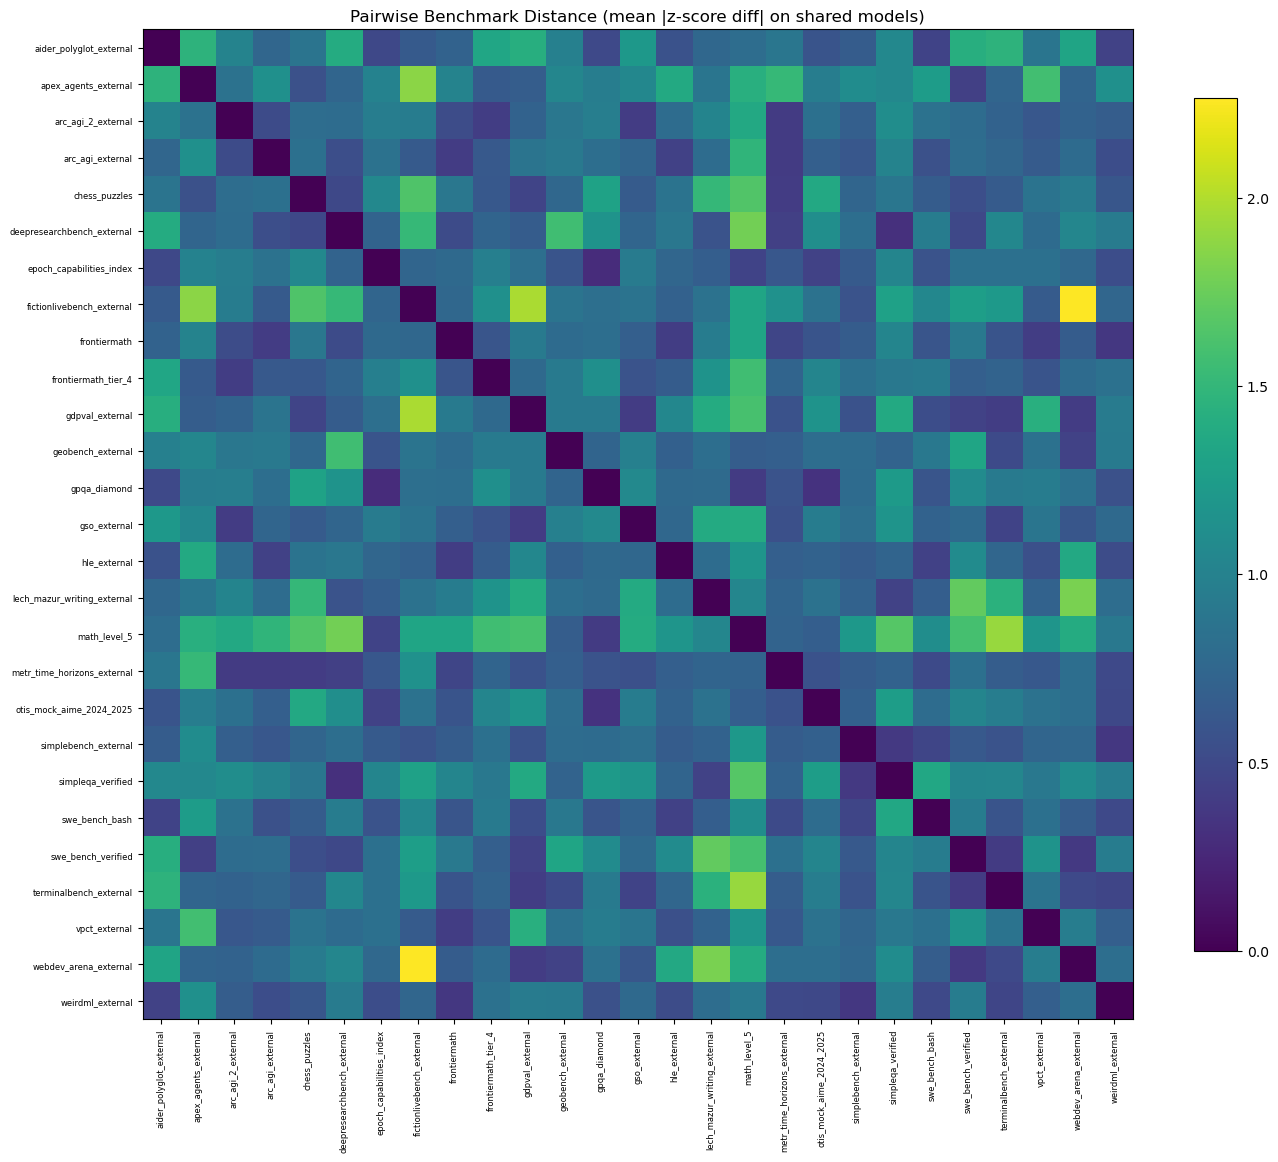

In [11]:
# Z-score each benchmark across its non-NaN values (do NOT fill NaN)
Z = (merged - merged.mean()) / merged.std()

benchmarks = Z.columns.tolist()
n_bm = len(benchmarks)

# Pairwise distance: mean |z_i - z_j| across shared models
# After filtering, every pair shares >= 1 model — no fallback needed
dist_matrix = np.zeros((n_bm, n_bm))
shared_counts = np.zeros((n_bm, n_bm), dtype=int)

for i in range(n_bm):
    for j in range(i + 1, n_bm):
        mask = Z[benchmarks[i]].notna() & Z[benchmarks[j]].notna()
        shared = mask.sum()
        shared_counts[i, j] = shared_counts[j, i] = shared
        d = (Z.loc[mask, benchmarks[i]] - Z.loc[mask, benchmarks[j]]).abs().mean()
        dist_matrix[i, j] = dist_matrix[j, i] = d

print(f"Distance matrix: {dist_matrix.shape}")
print(f"Shared model counts — min: {shared_counts[np.triu_indices(n_bm, k=1)].min()}, "
      f"median: {np.median(shared_counts[np.triu_indices(n_bm, k=1)]):.0f}, "
      f"max: {shared_counts[np.triu_indices(n_bm, k=1)].max()}")

# Show distance matrix as heatmap
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(dist_matrix, cmap='viridis')
ax.set_xticks(range(n_bm))
ax.set_yticks(range(n_bm))
ax.set_xticklabels(benchmarks, rotation=90, fontsize=6)
ax.set_yticklabels(benchmarks, fontsize=6)
ax.set_title('Pairwise Benchmark Distance (mean |z-score diff| on shared models)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

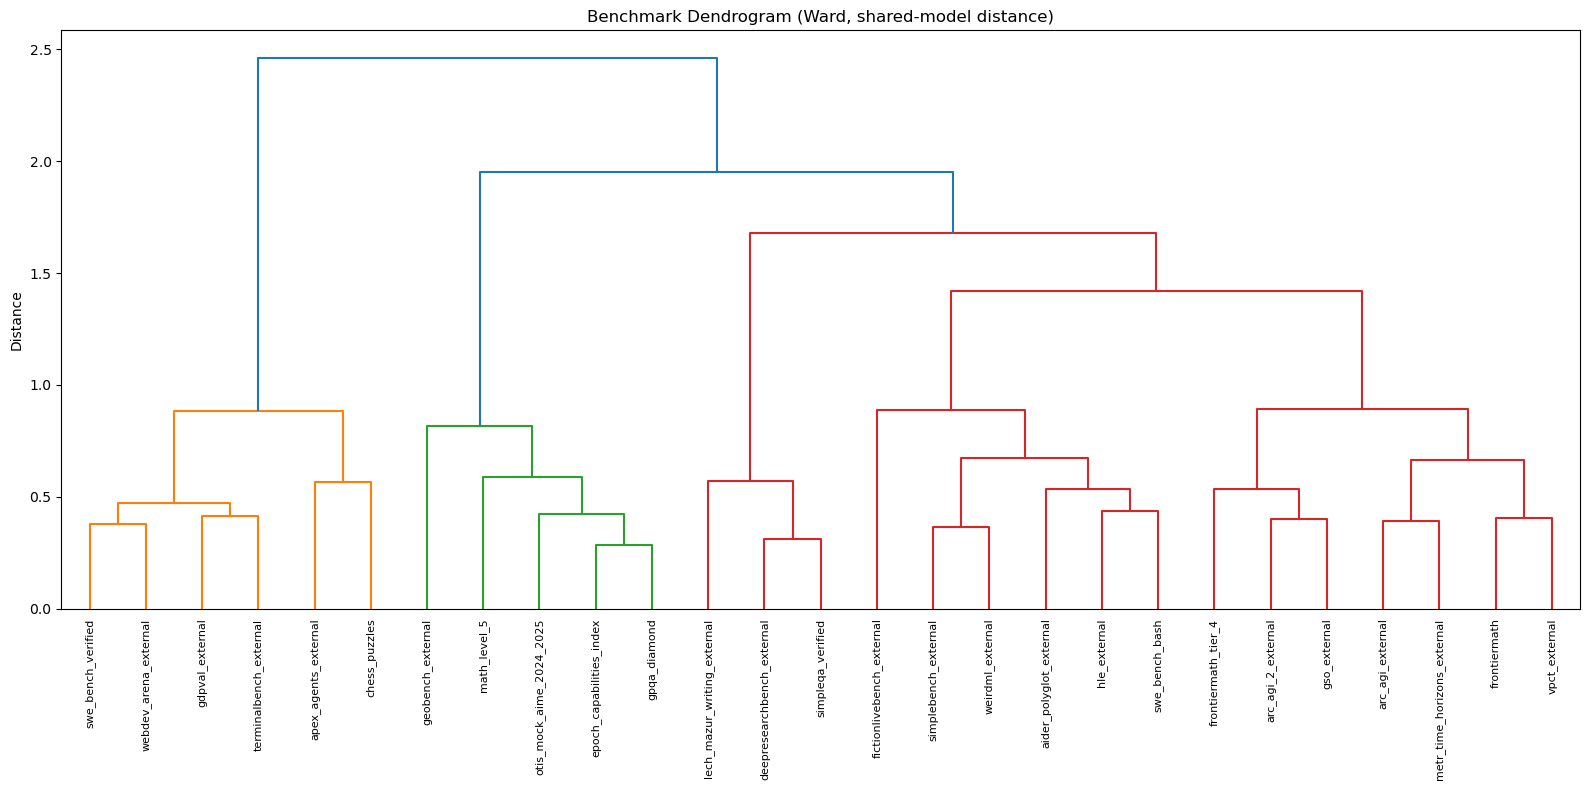

Cluster assignments at different cuts:

  k=2 (silhouette=0.222):
    Cluster 1: ['apex_agents_external', 'chess_puzzles', 'gdpval_external', 'swe_bench_verified', 'terminalbench_external', 'webdev_arena_external']
    Cluster 2: ['aider_polyglot_external', 'arc_agi_2_external', 'arc_agi_external', 'deepresearchbench_external', 'epoch_capabilities_index', 'fictionlivebench_external', 'frontiermath', 'frontiermath_tier_4', 'geobench_external', 'gpqa_diamond', 'gso_external', 'hle_external', 'lech_mazur_writing_external', 'math_level_5', 'metr_time_horizons_external', 'otis_mock_aime_2024_2025', 'simplebench_external', 'simpleqa_verified', 'swe_bench_bash', 'vpct_external', 'weirdml_external']

  k=3 (silhouette=0.195):
    Cluster 1: ['apex_agents_external', 'chess_puzzles', 'gdpval_external', 'swe_bench_verified', 'terminalbench_external', 'webdev_arena_external']
    Cluster 2: ['epoch_capabilities_index', 'geobench_external', 'gpqa_diamond', 'math_level_5', 'otis_mock_aime_2024_2025'

In [12]:
# Hierarchical clustering with dendrogram
condensed_dist = squareform(dist_matrix)
Z_linkage = linkage(condensed_dist, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(Z_linkage, labels=benchmarks, leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title('Benchmark Dendrogram (Ward, shared-model distance)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

print("Cluster assignments at different cuts:")
for n_clust in [2, 3, 4, 5, 6]:
    labels = fcluster(Z_linkage, t=n_clust, criterion='maxclust')
    sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    print(f"\n  k={n_clust} (silhouette={sil:.3f}):")
    for k in sorted(set(labels)):
        members = [benchmarks[i] for i in range(n_bm) if labels[i] == k]
        print(f"    Cluster {k}: {members}")

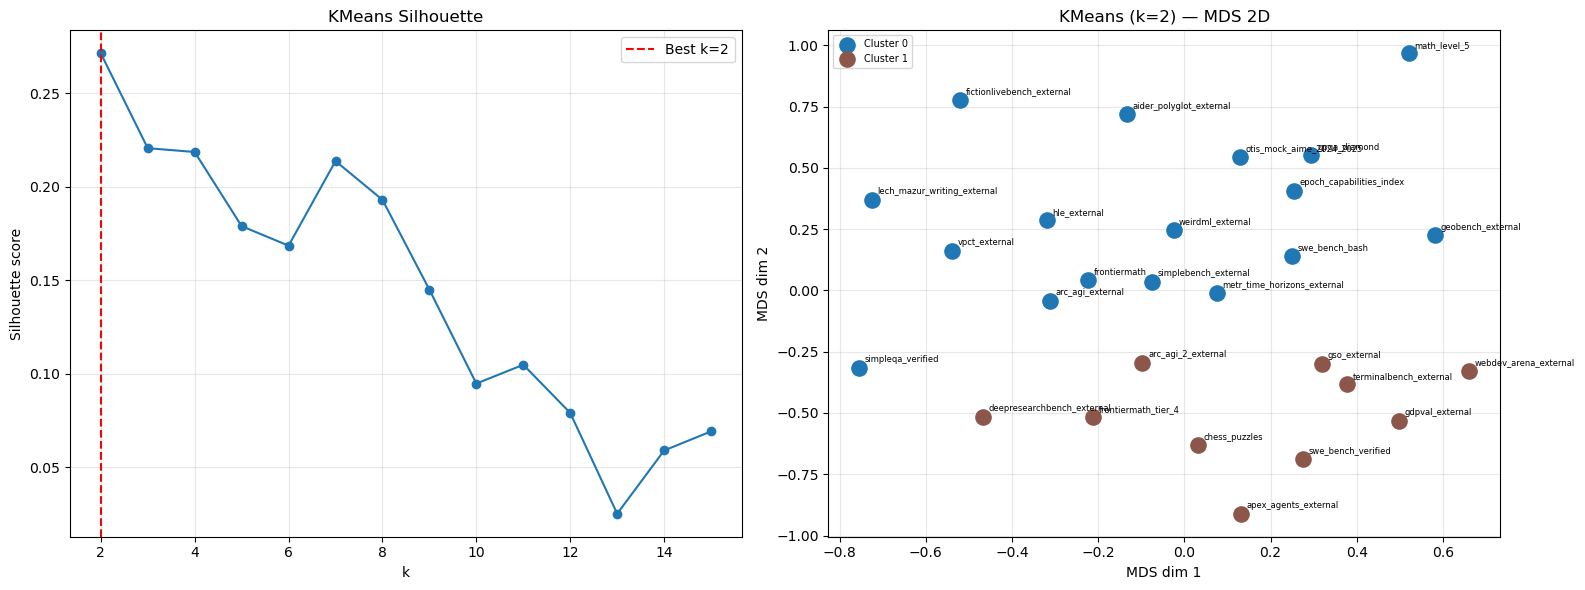


KMeans k=2:
  Cluster 0: ['aider_polyglot_external', 'arc_agi_external', 'epoch_capabilities_index', 'fictionlivebench_external', 'frontiermath', 'geobench_external', 'gpqa_diamond', 'hle_external', 'lech_mazur_writing_external', 'math_level_5', 'metr_time_horizons_external', 'otis_mock_aime_2024_2025', 'simplebench_external', 'simpleqa_verified', 'swe_bench_bash', 'vpct_external', 'weirdml_external']
  Cluster 1: ['apex_agents_external', 'arc_agi_2_external', 'chess_puzzles', 'deepresearchbench_external', 'frontiermath_tier_4', 'gdpval_external', 'gso_external', 'swe_bench_verified', 'terminalbench_external', 'webdev_arena_external']


In [13]:
# Embed distance matrix into coordinates with MDS for KMeans + visualization
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_2d = mds.fit_transform(dist_matrix)

# Also higher-D MDS for clustering
mds_highd = MDS(n_components=10, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_highd = mds_highd.fit_transform(dist_matrix)

# KMeans with silhouette sweep
sil_scores = []
k_range = range(2, 16)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(coords_highd)
    sil_scores.append(silhouette_score(dist_matrix, labels, metric='precomputed'))

best_k = list(k_range)[np.argmax(sil_scores)]
labels_km = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(coords_highd)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(list(k_range), sil_scores, 'o-')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('KMeans Silhouette')
axes[0].legend()
axes[0].grid(alpha=0.3)

colors = plt.cm.tab10(np.linspace(0, 1, max(best_k, 3)))
for k in range(best_k):
    mask = labels_km == k
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    color=colors[k], s=120, label=f'Cluster {k}', zorder=3)
for i, name in enumerate(benchmarks):
    axes[1].annotate(name, coords_2d[i], fontsize=6, xytext=(4, 4),
                     textcoords='offset points')
axes[1].set_xlabel('MDS dim 1')
axes[1].set_ylabel('MDS dim 2')
axes[1].set_title(f'KMeans (k={best_k}) — MDS 2D')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKMeans k={best_k}:")
for k in range(best_k):
    members = [benchmarks[i] for i in range(n_bm) if labels_km[i] == k]
    print(f"  Cluster {k}: {members}")

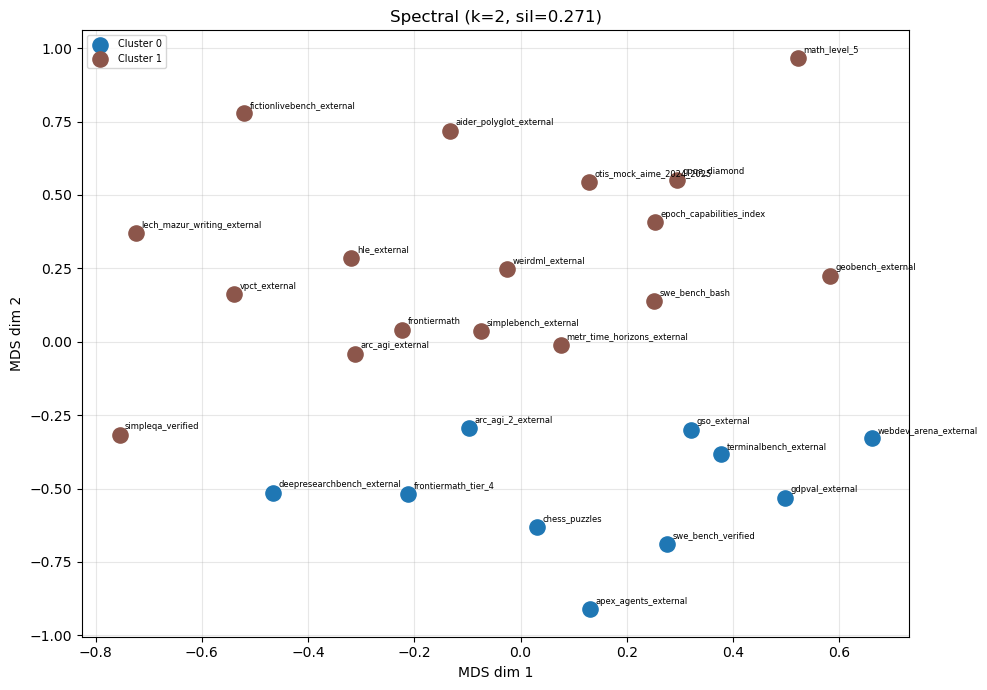


Spectral (k=2):
  Cluster 0: ['apex_agents_external', 'arc_agi_2_external', 'chess_puzzles', 'deepresearchbench_external', 'frontiermath_tier_4', 'gdpval_external', 'gso_external', 'swe_bench_verified', 'terminalbench_external', 'webdev_arena_external']
  Cluster 1: ['aider_polyglot_external', 'arc_agi_external', 'epoch_capabilities_index', 'fictionlivebench_external', 'frontiermath', 'geobench_external', 'gpqa_diamond', 'hle_external', 'lech_mazur_writing_external', 'math_level_5', 'metr_time_horizons_external', 'otis_mock_aime_2024_2025', 'simplebench_external', 'simpleqa_verified', 'swe_bench_bash', 'vpct_external', 'weirdml_external']


In [14]:
# Spectral clustering using precomputed similarity
# Convert distance to similarity: similarity = exp(-dist / median_dist)
median_dist = np.median(dist_matrix[dist_matrix > 0])
similarity = np.exp(-dist_matrix / median_dist)
np.fill_diagonal(similarity, 1.0)

best_sil_sc, best_k_sc, best_labels_sc = -1, 2, None
for k in range(2, 10):
    sc = SpectralClustering(n_clusters=k, affinity='precomputed', random_state=42)
    labels = sc.fit_predict(similarity)
    sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    if sil > best_sil_sc:
        best_sil_sc, best_k_sc, best_labels_sc = sil, k, labels

fig, ax = plt.subplots(figsize=(10, 7))
colors_sc = plt.cm.tab10(np.linspace(0, 1, max(best_k_sc, 3)))
for k in range(best_k_sc):
    mask = best_labels_sc == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               color=colors_sc[k], s=120, label=f'Cluster {k}', zorder=3)
for i, name in enumerate(benchmarks):
    ax.annotate(name, coords_2d[i], fontsize=6, xytext=(4, 4),
                textcoords='offset points')
ax.set_xlabel('MDS dim 1')
ax.set_ylabel('MDS dim 2')
ax.set_title(f'Spectral (k={best_k_sc}, sil={best_sil_sc:.3f})')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSpectral (k={best_k_sc}):")
for k in range(best_k_sc):
    members = [benchmarks[i] for i in range(n_bm) if best_labels_sc[i] == k]
    print(f"  Cluster {k}: {members}")

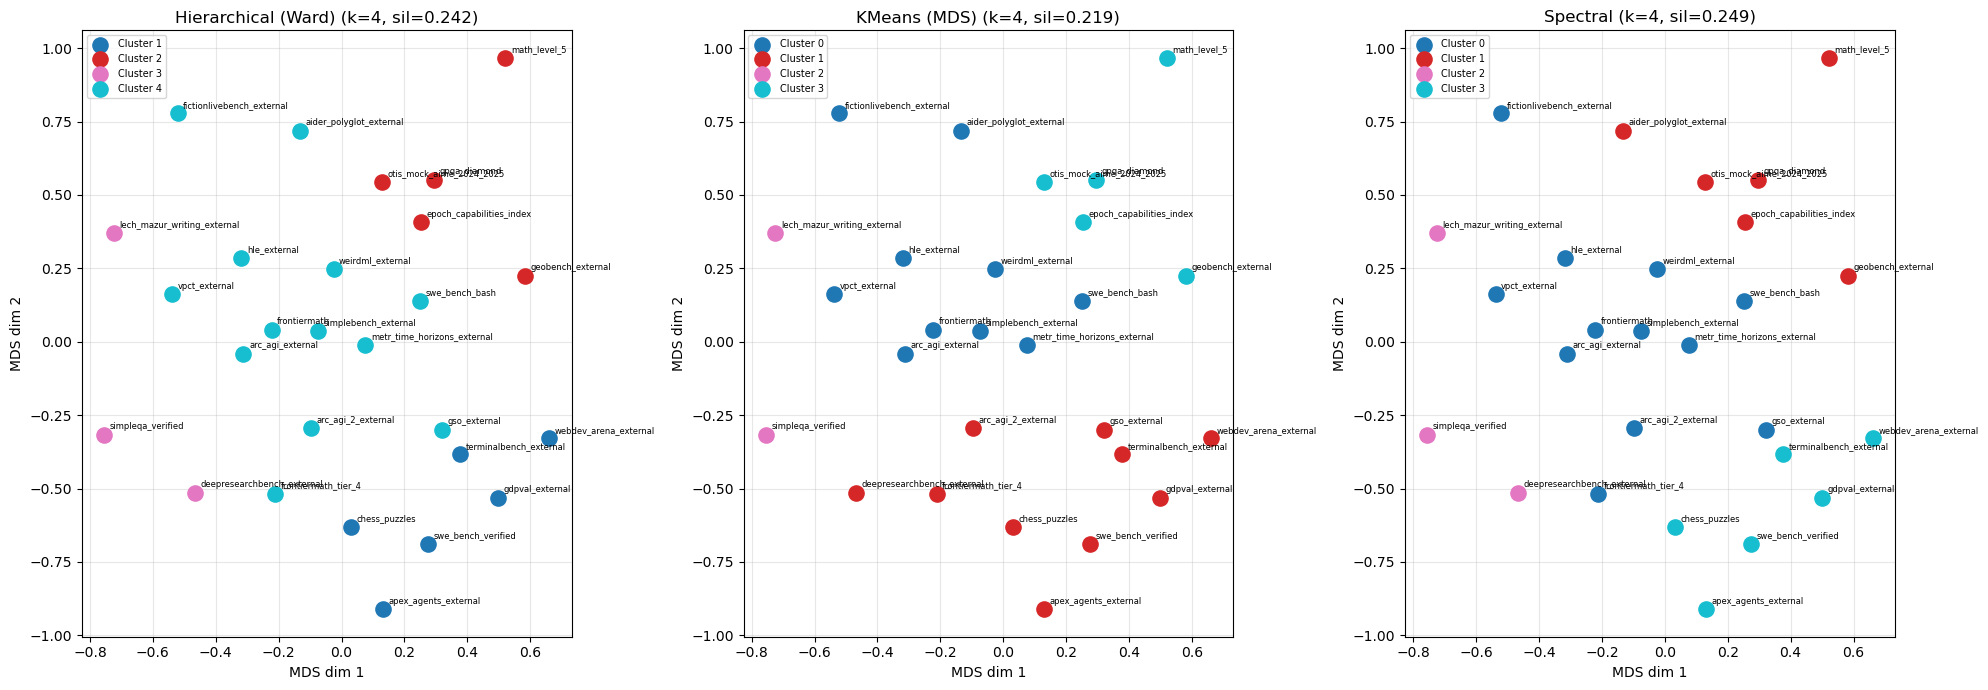


Hierarchical (Ward) (k=4):
  Cluster 1: ['apex_agents_external', 'chess_puzzles', 'gdpval_external', 'swe_bench_verified', 'terminalbench_external', 'webdev_arena_external']
  Cluster 2: ['epoch_capabilities_index', 'geobench_external', 'gpqa_diamond', 'math_level_5', 'otis_mock_aime_2024_2025']
  Cluster 3: ['deepresearchbench_external', 'lech_mazur_writing_external', 'simpleqa_verified']
  Cluster 4: ['aider_polyglot_external', 'arc_agi_2_external', 'arc_agi_external', 'fictionlivebench_external', 'frontiermath', 'frontiermath_tier_4', 'gso_external', 'hle_external', 'metr_time_horizons_external', 'simplebench_external', 'swe_bench_bash', 'vpct_external', 'weirdml_external']

KMeans (MDS) (k=4):
  Cluster 0: ['aider_polyglot_external', 'arc_agi_external', 'fictionlivebench_external', 'frontiermath', 'hle_external', 'metr_time_horizons_external', 'simplebench_external', 'swe_bench_bash', 'vpct_external', 'weirdml_external']
  Cluster 1: ['apex_agents_external', 'arc_agi_2_external', 

In [20]:
# Manual cluster count — set CHOSEN_K and re-run
CHOSEN_K = 4

methods = {
    'Hierarchical (Ward)': fcluster(Z_linkage, t=CHOSEN_K, criterion='maxclust'),
    'KMeans (MDS)': KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10).fit_predict(coords_highd),
    'Spectral': SpectralClustering(n_clusters=CHOSEN_K, affinity='precomputed',
                                    random_state=42).fit_predict(similarity),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (method_name, labels) in zip(axes, methods.items()):
    ulabels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(ulabels), 3)))
    for idx, k in enumerate(ulabels):
        mask = labels == k
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   color=colors[idx], s=120, label=f'Cluster {k}', zorder=3)
    for i, name in enumerate(benchmarks):
        ax.annotate(name, coords_2d[i], fontsize=6, xytext=(4, 4),
                    textcoords='offset points')
    sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    ax.set_xlabel('MDS dim 1')
    ax.set_ylabel('MDS dim 2')
    ax.set_title(f'{method_name} (k={CHOSEN_K}, sil={sil:.3f})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for method_name, labels in methods.items():
    print(f"\n{method_name} (k={CHOSEN_K}):")
    for k in sorted(set(labels)):
        members = [benchmarks[i] for i in range(n_bm) if labels[i] == k]
        print(f"  Cluster {k}: {members}")